# Norway Future Skills & Job Market Intelligence
## 03 — AI and Future Skills Analysis

### Main research question
**How is AI changing the Norwegian labor market, and what skills will matter in the future?**

### Objectives
This notebook focuses on four practical questions:

1. Which digital, data, software, automation, and AI-related skills appear in Norwegian job postings?
2. Which **specific skills** are most demanded?
3. Which job titles/categories and cities demand these skills?
4. What can a job seeker learn from these patterns?

### Methodological principle
The final AI/digital classification should not depend on a manually written keyword list.

Semantic clustering is used here as an **exploratory tool** to understand the skill vocabulary.  
The final digital-skill classification will be standardized against **ESCO**, the European multilingual skills and occupations taxonomy.

## 1. Load the prepared skill-level dataset

Data collection, cleaning, missing-value handling, and skill extraction were completed in earlier notebooks.

This notebook starts from:

`data/processed/skills_jobs_analysis.csv`

The main fields used here are:

- `job_id`
- `skill`
- `title`
- `category`
- `city`

### Important limitation: occupation

Earlier data-quality analysis showed that the `occupation` field is unavailable or unreliable for most postings.

**Decision:** `occupation` is not used as a core variable in this notebook.  
Job context will instead come from `title`, `category`, and `city`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

skills_jobs_df = pd.read_csv(
    "../data/processed/skills_jobs_analysis.csv"
)

skills_jobs_df.head()

,job_id,skills,skill,city,category,occupation,title
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...


In [2]:
print("Shape:", skills_jobs_df.shape)
print("Unique jobs:", skills_jobs_df["job_id"].nunique())
print("Unique skills:", skills_jobs_df["skill"].nunique())

skills_jobs_df[
    ["job_id", "skill", "title", "category", "city"]
].isna().sum()

Shape: (95324, 7)
Unique jobs: 10000
Unique skills: 10997


job_id      0
skill       0
title       0
category    0
city        0
dtype: int64

### Interpretation

Each row represents a **job-skill relationship**, not a unique job posting.

Therefore:

- skill demand should be measured with **unique `job_id` counts**
- job demand should also use **unique `job_id` counts**
- raw row counts should not automatically be interpreted as numbers of jobs

## 2. Build the full skill vocabulary

We first create one row per unique observed skill.

Unlike the earlier exploratory code, frequency is defined as the number of **unique job postings** containing a skill.

In [3]:
skill_vocabulary = (
    skills_jobs_df
    .groupby("skill")
    .agg(job_frequency=("job_id", "nunique"))
    .reset_index()
    .sort_values("job_frequency", ascending=False)
)

skill_vocabulary.head(20)

,skill,job_frequency
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


In [4]:
print("Unique observed skills:", skill_vocabulary.shape[0])

skill_vocabulary["job_frequency"].describe()

Unique observed skills: 10997


count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: job_frequency, dtype: float64

### Interpretation

The vocabulary contains a large long tail:

- a relatively small number of skills appear in many postings
- many skills appear only a few times

This is normal in real job-posting data and can reflect specialization, terminology variation, and niche requirements.

We **do not delete rare skills from the final analysis**, because a new or specialized AI skill may be rare but still meaningful.

# Part A — Exploratory semantic clustering

## 3. Create a reduced vocabulary for exploratory clustering

Clustering all very rare skills can make exploratory groups difficult to interpret.

For **clustering only**, we keep skills appearing in at least 5 jobs.

This filter is not applied to the final ESCO classification.

In [5]:
cluster_vocabulary = skill_vocabulary[
    skill_vocabulary["job_frequency"] >= 5
].copy()

cluster_vocabulary.shape

(2423, 2)

## 4. Create multilingual skill embeddings

Job-posting skills contain both Norwegian and English terminology.

A multilingual Sentence Transformer converts each skill into a semantic vector, allowing similar concepts to be close even when their wording or language differs.

Embeddings are normalized because semantic similarity is naturally evaluated with cosine similarity, and normalized vectors provide a cleaner representation for this exploratory clustering.

In [6]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

cluster_embeddings = embedding_model.encode(
    cluster_vocabulary["skill"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

cluster_embeddings.shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

(2423, 384)

## 5. Select a reasonable exploratory number of clusters

There is no universally correct number of clusters for a semantic skill vocabulary.

We use two diagnostics:

- **Elbow / inertia:** how compact the clusters become as `k` increases
- **Silhouette score:** how separated the resulting groups are

For text embeddings, a perfectly sharp elbow or very high silhouette score is not expected because many skills overlap semantically.

The goal is **interpretability**, not perfect machine-learning separation.

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidate_k = [10, 20, 30, 40, 50]
inertias = []
silhouette_scores = []

for k in candidate_k:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = km.fit_predict(cluster_embeddings)

    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(cluster_embeddings, labels)
    )

cluster_diagnostics = pd.DataFrame({
    "k": candidate_k,
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

cluster_diagnostics

,k,inertia,silhouette_score
0,10,1200.610352,0.072138
1,20,1094.565918,0.047138
2,30,1025.380615,0.057973
3,40,969.983643,0.062711
4,50,931.008301,0.084175


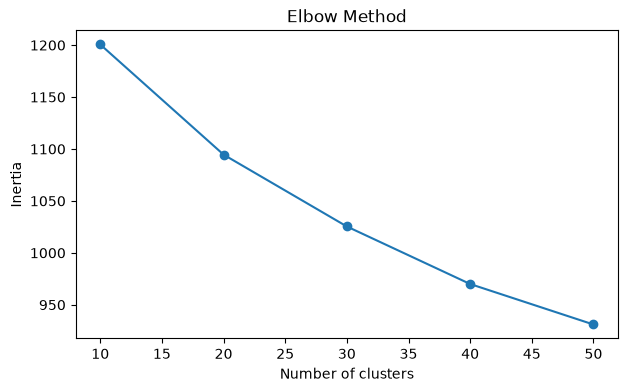

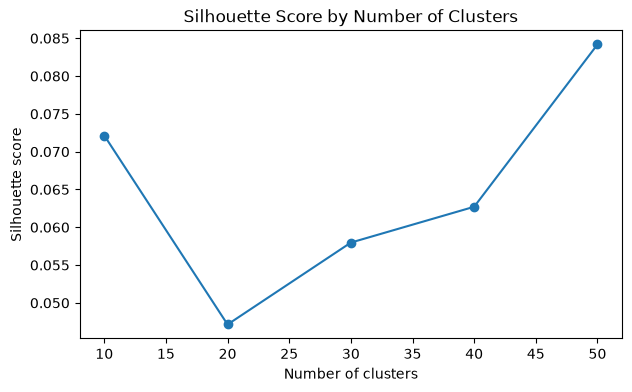

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

### Interpretation

Among the tested values, k=50 produced the highest silhouette score (~0.084). The scores remain relatively low overall, indicating overlapping semantic structure. Since clustering is exploratory rather than the final classifier, k=50 is retained as a practical exploratory solution.

In [9]:
SELECTED_K = 50

kmeans = KMeans(
    n_clusters=SELECTED_K,
    random_state=42,
    n_init=10
)

cluster_vocabulary["cluster"] = kmeans.fit_predict(
    cluster_embeddings
)

cluster_vocabulary.head()

,skill,job_frequency,cluster
6217,Omsorg,1471,37
4801,Kundeservice,1396,25
3267,Helse,1106,41
1269,Butikk,1057,0
7597,Salg,981,0


## 6. Inspect the semantic clusters

The purpose of clustering is to discover broad structures in the vocabulary.

It is **not** used to say that every skill in a cluster belongs to the same final future-skill category.

In [10]:
cluster_summary = (
    cluster_vocabulary
    .sort_values(
        ["cluster", "job_frequency"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .head(10)
)

for cluster_id in sorted(cluster_summary["cluster"].unique()):
    skills = (
        cluster_summary.loc[
            cluster_summary["cluster"] == cluster_id,
            "skill"
        ]
        .tolist()
    )

    print(f"CLUSTER {cluster_id}")
    print(", ".join(skills))
    print()

CLUSTER 0
Butikk, Salg, Butikkmedarbeider, Kundebehandling, Butikkselger, Innkjøp, Butikkleder, Detaljhandel, Butikksjef, Markedsføring

CLUSTER 1
Barnehage, Matlaging, Akuttmedisin, Rydding, Primærkontakt, Allmennmedisin, Tekstil, Håndverk, Optikk, Hårklipp

CLUSTER 2
Strategi, Installasjon, Python, Systemutvikling, Programmering, Prosessforbedring, Systemutvikler, Programmerer, Teknisk forståelse, Teknisk support

CLUSTER 3
Dokumentasjon, Rapportering, Arkiv, Sosiale medier, Journalføring, Fakturering, Bibliotek, Journalsystem, Dokumentforvaltning, Video

CLUSTER 4
Hjemmetjeneste, Bolig, Husarbeid, Hjemmehjelp, Eiendom, Eiendomsforvaltning, Hjemmebasert omsorg, hjemmetjeneste, Hjemmekontor, Møbler

CLUSTER 5
Rådgiver, Pasientbehandling, Saksbehandling, Sykehjem, Rådgivning, Praktisk bistand, Ekstrahjelp, Behandling, Gjestebehandling, omsorg

CLUSTER 6
Ingeniør, Teknologi, Håndverker, Teknisk drift, Teknisk dokumentasjon, Tekniker, Prosjektingeniør, Teknisk arbeid, Teknisk tegning, Se

### What the clustering taught us

The exploratory clusters successfully reveal broad semantic areas such as data, software, healthcare, engineering, administration, and digitalization.

However, some clusters also mix relevant and irrelevant concepts.

For example, a technology-oriented cluster may also contain mechanical or operational skills, while an analysis-oriented cluster may contain unrelated support roles.

### Why this happens

KMeans must assign **every observation** to one cluster. It does not have a concept of:

> "This skill does not belong to the AI/digital domain."

Therefore:

**We keep clustering as exploratory evidence, but we do not use whole clusters as the final AI/digital classification.**

This avoids conclusions such as:

- assigning BPA to "Analysis & Reporting"
- assigning a mechanic skill to "AI & Software"
- treating a whole mixed cluster as a future-skill domain

# Part B — Final digital-skill classification with ESCO

## 7. Why use ESCO?

For the final classification, we need an external reference that is:

- designed for labor-market analysis
- multilingual
- based on standardized skill concepts
- able to distinguish digital skills without a manually written keyword list

ESCO (European Skills, Competences, Qualifications and Occupations) provides:

- a multilingual European skill taxonomy
- unique concept URIs
- Norwegian and English labels
- an official `digitalSkillsCollection`

### Key methodological change

We will map **all observed NAV skills** to **all ESCO skill concepts**.

Only after finding the best ESCO concept do we ask whether that ESCO concept has the official digital label.

This is important.

If we matched NAV skills only against digital ESCO skills, a non-digital skill would be forced to match *some* digital skill.  
By matching against **all ESCO skills first**, unrelated skills can map to non-digital ESCO concepts and remain excluded.

Official sources:

- https://esco.ec.europa.eu/en/use-esco/download
- https://esco.ec.europa.eu/en/about-esco/escopedia/escopedia/digital-skills-labelling-esco

## 8. Download and place ESCO data

Download the latest ESCO classification in **CSV** format for:

- Norwegian (`no`)
- English (`en`)

Extract the files somewhere under:

`data/external/esco/`

The downloaded package should contain files whose names begin with:

- `skills_`
- `digitalSkillsCollection_`

The code below searches subfolders automatically, so the exact extraction folder name is not important.

In [11]:
from pathlib import Path

ESCO_ROOT = Path("../data/external/esco").resolve()

print("ESCO folder:", ESCO_ROOT)
print("Exists:", ESCO_ROOT.exists())

csv_files = list(ESCO_ROOT.rglob("*.csv"))

print("CSV files found:", len(csv_files))

for file in csv_files:
    print(file.relative_to(ESCO_ROOT))

ESCO folder: E:\@UIO\Python\Norway-future-skills\data\external\esco
Exists: True
CSV files found: 37
norwegian\v1.2.1\broaderRelationsOccPillar_no.csv
norwegian\v1.2.1\broaderRelationsSkillPillar_no.csv
norwegian\v1.2.1\dictionary_no.csv
norwegian\v1.2.1\digCompSkillsCollection_no.csv
norwegian\v1.2.1\digitalSkillsCollection_no.csv
norwegian\v1.2.1\greenShareOcc_no.csv
norwegian\v1.2.1\greenSkillsCollection_no.csv
norwegian\v1.2.1\ISCOGroups_no.csv
norwegian\v1.2.1\languageSkillsCollection_no.csv
norwegian\v1.2.1\occupationSkillRelations_no.csv
norwegian\v1.2.1\occupations_no.csv
norwegian\v1.2.1\researchOccupationsCollection_no.csv
norwegian\v1.2.1\researchSkillsCollection_no.csv
norwegian\v1.2.1\skillGroups_no.csv
norwegian\v1.2.1\skillsHierarchy_no.csv
norwegian\v1.2.1\skillSkillRelations_no.csv
norwegian\v1.2.1\skills_no.csv
norwegian\v1.2.1\transversalSkillsCollection_no.csv
english\v1.2.1\broaderRelationsOccPillar_en.csv
english\v1.2.1\broaderRelationsSkillPillar_en.csv
english\v

In [12]:
from pathlib import Path

ESCO_ROOT = Path("../data/external/esco").resolve()

def find_esco_file(filename):
    matches = list(ESCO_ROOT.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename} under {ESCO_ROOT}"
        )

    if len(matches) > 1:
        print(f"Warning: multiple files found for {filename}")
        for file in matches:
            print(file)

    return matches[0]


skills_no_path = find_esco_file("skills_no.csv")
skills_en_path = find_esco_file("skills_en.csv")

digital_no_path = find_esco_file(
    "digitalSkillsCollection_no.csv"
)

digital_en_path = find_esco_file(
    "digitalSkillsCollection_en.csv"
)


print("Norwegian skills:")
print(skills_no_path)

print("\nEnglish skills:")
print(skills_en_path)

print("\nNorwegian digital skills:")
print(digital_no_path)

print("\nEnglish digital skills:")
print(digital_en_path)

Norwegian skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\norwegian\v1.2.1\skills_no.csv

English skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\english\v1.2.1\skills_en.csv

Norwegian digital skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\norwegian\v1.2.1\digitalSkillsCollection_no.csv

English digital skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\english\v1.2.1\digitalSkillsCollection_en.csv


## 9. Load ESCO skills and the official digital collection

ESCO files can change slightly between releases, so the helper functions below detect the URI and label columns instead of assuming one exact column layout.

In [13]:
def read_esco_csv(path):
    try:
        return pd.read_csv(
            path,
            encoding="utf-8-sig"
        )
    except Exception:
        return pd.read_csv(
            path,
            encoding="utf-8-sig",
            sep=None,
            engine="python"
        )

esco_skills_no = read_esco_csv(skills_no_path)
esco_skills_en = read_esco_csv(skills_en_path)

esco_digital_no = read_esco_csv(digital_no_path)
esco_digital_en = read_esco_csv(digital_en_path)

print("Norwegian skills:", esco_skills_no.shape)
print("English skills:", esco_skills_en.shape)
print("Norwegian digital collection:", esco_digital_no.shape)
print("English digital collection:", esco_digital_en.shape)

Norwegian skills: (13960, 13)
English skills: (13960, 13)
Norwegian digital collection: (1284, 10)
English digital collection: (1284, 10)


In [14]:
def detect_column(df, candidates, required=True):
    lookup = {
        str(col).strip().lower(): col
        for col in df.columns
    }

    for candidate in candidates:
        key = candidate.lower()
        if key in lookup:
            return lookup[key]

    if required:
        raise KeyError(
            f"None of {candidates} found. "
            f"Available columns: {list(df.columns)}"
        )

    return None

def prepare_esco_language(skills_df, language):
    uri_col = detect_column(
        skills_df,
        ["conceptUri", "conceptURI", "uri"]
    )

    label_col = detect_column(
        skills_df,
        ["preferredLabel", "preferredTerm", "label"]
    )

    result = skills_df[
        [uri_col, label_col]
    ].copy()

    result.columns = [
        "esco_uri",
        "esco_label"
    ]

    result["language"] = language

    return result.dropna().drop_duplicates()

esco_labels = pd.concat(
    [
        prepare_esco_language(
            esco_skills_no,
            "no"
        ),
        prepare_esco_language(
            esco_skills_en,
            "en"
        )
    ],
    ignore_index=True
).drop_duplicates()

esco_labels.head()

,esco_uri,esco_label,language
0,http://data.europa.eu/esco/skill/0005c151-5b5a...,administrere musikkpersonell,no
1,http://data.europa.eu/esco/skill/00064735-8fad...,overvåke fengselsprosedyrer,no
2,http://data.europa.eu/esco/skill/000709ed-2be5...,anvende undertrykkelsesmotvirkende praksis,no
3,http://data.europa.eu/esco/skill/0007bdc2-dd15...,kontrollere samsvar med forskrifter for jernba...,no
4,http://data.europa.eu/esco/skill/00090cc1-1f27...,identifisere tilgjengelige tjenester,no


In [15]:
def get_uri_set(collection_df):
    uri_col = detect_column(
        collection_df,
        ["conceptUri", "conceptURI", "uri"]
    )

    return set(
        collection_df[uri_col]
        .dropna()
        .astype(str)
    )

digital_uris = (
    get_uri_set(esco_digital_no)
    | get_uri_set(esco_digital_en)
)

esco_labels["is_digital_esco"] = (
    esco_labels["esco_uri"]
    .astype(str)
    .isin(digital_uris)
)

print(
    "ESCO concepts labelled digital:",
    esco_labels.loc[
        esco_labels["is_digital_esco"],
        "esco_uri"
    ].nunique()
)

ESCO concepts labelled digital: 1284


The number of officially labelled digital skills depends on the ESCO release. In ESCO v1.2.1 used in this analysis, 1,284 unique concepts are included in the digital skills collection.

In [16]:
print(esco_skills_no.columns.tolist())

['conceptType', 'conceptUri', 'skillType', 'reuseLevel', 'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate', 'scopeNote', 'definition', 'inScheme', 'description']


In [17]:
esco_skills_no.head(2)

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,administrere musikkpersonell,NaN,NaN,released,2023-11-30T15:53:37.136Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Tildele og administrere personaloppgaver på om...
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,overvåke fengselsprosedyrer,NaN,NaN,released,2023-11-30T15:04:00.689Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Føre tilsyn med driften av fengsler eller andr...


### Interpretation

The ESCO digital label is now attached through the **concept URI**, not through our own keywords.

The next task is to map each observed NAV skill to its closest ESCO concept.

## 10. Match NAV skills to ESCO concepts

The goal is to standardize the observed NAV skill vocabulary against ESCO.

A two-stage matching strategy is used:

1. **Exact label matching**
   - First compare NAV skills with ESCO preferred and alternative labels.
   - Exact matches are accepted only when the label maps unambiguously to one ESCO concept.

2. **Semantic matching**
   - Skills without an unambiguous exact match are matched using multilingual sentence embeddings.
   - Semantic similarity is calculated against both Norwegian and English ESCO labels.

This approach is preferable to using semantic matching alone because exact terminology should not require a machine-learning approximation.

The official ESCO digital label is applied only **after** a NAV skill has been mapped to an ESCO concept.

In [ ]:
import re
import ast
import unicodedata


def normalize_label(text):
    """
    Normalize labels for exact matching without changing
    their underlying meaning.
    """
    if pd.isna(text):
        return ""

    text = unicodedata.normalize(
        "NFKC",
        str(text)
    )

    text = text.casefold().strip()

    # Collapse repeated whitespace
    text = re.sub(r"\s+", " ", text)

    return text


def split_alt_labels(value):
    """
    Convert the ESCO altLabels field into individual labels.

    Handles:
    - missing values
    - list-like values
    - newline-separated values
    - semicolon-separated values
    - pipe-separated values

    Commas are intentionally NOT used as separators because
    they may legitimately occur inside a label.
    """
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        return [
            str(x).strip()
            for x in value
            if str(x).strip()
        ]

    text = str(value).strip()

    if not text:
        return []

    # Handle strings that look like Python lists
    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, (list, tuple, set)):
            return [
                str(x).strip()
                for x in parsed
                if str(x).strip()
            ]
    except (ValueError, SyntaxError):
        pass

    # Handle escaped newlines if present
    text = text.replace("\\n", "\n")

    parts = re.split(
        r"\s*(?:\r?\n|;|\|)\s*",
        text
    )

    return [
        part.strip()
        for part in parts
        if part.strip()
    ]

In [19]:
def build_esco_label_reference(
    skills_df,
    language
):
    records = []

    for _, row in skills_df.iterrows():

        uri = str(row["conceptUri"])

        preferred = row["preferredLabel"]

        if pd.notna(preferred):

            records.append({
                "esco_uri": uri,
                "esco_match_label": str(preferred).strip(),
                "label_type": "preferred",
                "language": language
            })

        for alt_label in split_alt_labels(
            row["altLabels"]
        ):

            records.append({
                "esco_uri": uri,
                "esco_match_label": alt_label,
                "label_type": "alternative",
                "language": language
            })

    return pd.DataFrame(records)


esco_reference_no = build_esco_label_reference(
    esco_skills_no,
    "no"
)

esco_reference_en = build_esco_label_reference(
    esco_skills_en,
    "en"
)


esco_label_reference = pd.concat(
    [
        esco_reference_no,
        esco_reference_en
    ],
    ignore_index=True
)


# Normalize labels for exact matching
esco_label_reference[
    "label_normalized"
] = (
    esco_label_reference[
        "esco_match_label"
    ]
    .apply(normalize_label)
)


# Attach official ESCO digital classification
esco_label_reference[
    "is_digital_esco"
] = (
    esco_label_reference[
        "esco_uri"
    ]
    .isin(digital_uris)
)


# Remove duplicate label/concept combinations
esco_label_reference = (
    esco_label_reference
    .drop_duplicates(
        subset=[
            "esco_uri",
            "label_normalized",
            "language"
        ]
    )
    .reset_index(drop=True)
)


print(
    "ESCO searchable labels:",
    len(esco_label_reference)
)

print(
    "Unique ESCO concepts:",
    esco_label_reference[
        "esco_uri"
    ].nunique()
)

print(
    "Digital ESCO concepts:",
    esco_label_reference.loc[
        esco_label_reference[
            "is_digital_esco"
        ],
        "esco_uri"
    ].nunique()
)

esco_label_reference.head()

ESCO searchable labels: 119180
Unique ESCO concepts: 13939
Digital ESCO concepts: 1284


,esco_uri,esco_match_label,label_type,language,label_normalized,is_digital_esco
0,http://data.europa.eu/esco/skill/0005c151-5b5a...,administrere musikkpersonell,preferred,no,administrere musikkpersonell,False
1,http://data.europa.eu/esco/skill/00064735-8fad...,overvåke fengselsprosedyrer,preferred,no,overvåke fengselsprosedyrer,False
2,http://data.europa.eu/esco/skill/000709ed-2be5...,anvende undertrykkelsesmotvirkende praksis,preferred,no,anvende undertrykkelsesmotvirkende praksis,False
3,http://data.europa.eu/esco/skill/0007bdc2-dd15...,kontrollere samsvar med forskrifter for jernba...,preferred,no,kontrollere samsvar med forskrifter for jernba...,False
4,http://data.europa.eu/esco/skill/00090cc1-1f27...,identifisere tilgjengelige tjenester,preferred,no,identifisere tilgjengelige tjenester,False


In [20]:
nav_skill_reference = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        job_frequency=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)


nav_skill_reference[
    "skill_normalized"
] = (
    nav_skill_reference[
        "skill"
    ]
    .apply(normalize_label)
)


exact_candidates = (
    nav_skill_reference
    .merge(
        esco_label_reference,
        left_on="skill_normalized",
        right_on="label_normalized",
        how="inner"
    )
)


# Check whether an exact label points to
# more than one different ESCO concept
exact_uri_counts = (
    exact_candidates
    .groupby("skill")[
        "esco_uri"
    ]
    .nunique()
)


unambiguous_exact_skills = set(
    exact_uri_counts[
        exact_uri_counts == 1
    ].index
)


ambiguous_exact_skills = set(
    exact_uri_counts[
        exact_uri_counts > 1
    ].index
)


exact_matches = (
    exact_candidates[
        exact_candidates[
            "skill"
        ].isin(
            unambiguous_exact_skills
        )
    ]
    # Prefer preferred labels when both
    # preferred and alternative labels match
    .assign(
        label_priority=lambda x:
        x["label_type"].map({
            "preferred": 0,
            "alternative": 1
        })
    )
    .sort_values(
        [
            "skill",
            "label_priority"
        ]
    )
    .drop_duplicates(
        subset="skill"
    )
)


exact_matches = exact_matches[
    [
        "skill",
        "job_frequency",
        "esco_uri",
        "esco_match_label",
        "language",
        "is_digital_esco"
    ]
].copy()


exact_matches = exact_matches.rename(
    columns={
        "esco_match_label": "esco_label",
        "language": "esco_language"
    }
)


exact_matches[
    "match_method"
] = "exact"

exact_matches[
    "match_score"
] = 1.0

exact_matches[
    "second_best_score"
] = np.nan

exact_matches[
    "match_margin"
] = np.nan


print(
    "NAV skills:",
    len(nav_skill_reference)
)

print(
    "Unambiguous exact matches:",
    len(exact_matches)
)

print(
    "Ambiguous exact labels:",
    len(ambiguous_exact_skills)
)

print(
    "Remaining for semantic matching:",
    len(nav_skill_reference)
    - len(exact_matches)
)

NAV skills: 10997
Unambiguous exact matches: 456
Ambiguous exact labels: 12
Remaining for semantic matching: 10541


In [21]:
from sentence_transformers import util


exact_matched_skills = set(
    exact_matches["skill"]
)


semantic_nav_skills = (
    nav_skill_reference[
        ~nav_skill_reference[
            "skill"
        ].isin(
            exact_matched_skills
        )
    ]
    .reset_index(drop=True)
)


print(
    "Skills requiring semantic matching:",
    len(semantic_nav_skills)
)


semantic_nav_embeddings = (
    embedding_model.encode(
        semantic_nav_skills[
            "skill"
        ].tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
)


esco_reference_embeddings = (
    embedding_model.encode(
        esco_label_reference[
            "esco_match_label"
        ].tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
)

Skills requiring semantic matching: 10541


Batches:   0%|          | 0/330 [00:00<?, ?it/s]

Batches:   0%|          | 0/3725 [00:00<?, ?it/s]

In [22]:
semantic_hits = util.semantic_search(
    semantic_nav_embeddings,
    esco_reference_embeddings,
    top_k=20
)


semantic_match_records = []


for nav_index, hits in enumerate(
    semantic_hits
):

    best_by_uri = {}

    for hit in hits:

        esco_row = (
            esco_label_reference
            .iloc[
                hit["corpus_id"]
            ]
        )

        uri = str(
            esco_row["esco_uri"]
        )

        score = float(
            hit["score"]
        )


        # Keep only the best label
        # representing each ESCO concept
        if (
            uri not in best_by_uri
            or score
            > best_by_uri[uri][
                "score"
            ]
        ):

            best_by_uri[uri] = {
                "score": score,

                "label":
                    esco_row[
                        "esco_match_label"
                    ],

                "language":
                    esco_row[
                        "language"
                    ],

                "is_digital_esco":
                    bool(
                        esco_row[
                            "is_digital_esco"
                        ]
                    )
            }


    unique_matches = sorted(
        best_by_uri.items(),
        key=lambda item:
        item[1]["score"],
        reverse=True
    )


    best_uri, best = (
        unique_matches[0]
    )


    second_score = (
        unique_matches[1][1][
            "score"
        ]
        if len(unique_matches) > 1
        else np.nan
    )


    semantic_match_records.append({

        "skill":
            semantic_nav_skills.loc[
                nav_index,
                "skill"
            ],

        "job_frequency":
            semantic_nav_skills.loc[
                nav_index,
                "job_frequency"
            ],

        "esco_uri":
            best_uri,

        "esco_label":
            best["label"],

        "esco_language":
            best["language"],

        "match_method":
            "semantic",

        "match_score":
            best["score"],

        "second_best_score":
            second_score,

        "match_margin":
            (
                best["score"]
                - second_score
                if pd.notna(
                    second_score
                )
                else np.nan
            ),

        "is_digital_esco":
            best[
                "is_digital_esco"
            ]
    })


semantic_matches = pd.DataFrame(
    semantic_match_records
)

In [23]:
esco_matches = pd.concat(
    [
        exact_matches,
        semantic_matches
    ],
    ignore_index=True
)


print(
    "Total NAV skills:",
    nav_skill_reference[
        "skill"
    ].nunique()
)

print(
    "Total mapped skills:",
    esco_matches[
        "skill"
    ].nunique()
)

print("\nMatch methods:")

print(
    esco_matches[
        "match_method"
    ].value_counts()
)


print(
    "\nMapped to digital ESCO concepts:",
    esco_matches.loc[
        esco_matches[
            "is_digital_esco"
        ],
        "skill"
    ].nunique()
)


esco_matches[
    [
        "skill",
        "job_frequency",
        "esco_label",
        "esco_language",
        "match_method",
        "match_score",
        "match_margin",
        "is_digital_esco"
    ]
].sort_values(
    [
        "match_method",
        "job_frequency"
    ],
    ascending=[
        True,
        False
    ]
).head(30)

Total NAV skills: 10997
Total mapped skills: 10997

Match methods:
match_method
semantic    10541
exact         456
Name: count, dtype: int64

Mapped to digital ESCO concepts: 1733


,skill,job_frequency,esco_label,esco_language,match_method,match_score,match_margin,is_digital_esco
207,Kundeservice,1396,kundeservice,no,exact,1.0,NaN,False
289,Prosjektledelse,446,prosjektledelse,no,exact,1.0,NaN,False
260,Offentlig forvaltning,337,offentlig forvaltning,no,exact,1.0,NaN,False
451,Økonomi,325,økonomi,no,exact,1.0,NaN,False
223,Logistikk,321,logistikk,no,exact,1.0,NaN,False
301,Rehabilitering,269,rehabilitering,no,exact,1.0,NaN,False
275,Pedagogikk,224,pedagogikk,no,exact,1.0,NaN,False
300,Regnskap,222,regnskap,no,exact,1.0,NaN,False
67,Digitalisering,186,digitalisering,no,exact,1.0,NaN,True
358,Transport,179,transport,en,exact,1.0,NaN,False


In [30]:
def representative_values(series, n=5):
    """
    Return the most common meaningful values
    associated with a skill.
    """
    values = (
        series
        .dropna()
        .astype(str)
    )

    values = values[
        ~values.str.lower().eq("not classified")
    ]

    return values.value_counts().head(n).index.tolist()


skill_context = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        example_titles=(
            "title",
            representative_values
        ),
        example_categories=(
            "category",
            representative_values
        )
    )
    .reset_index()
)


def build_nav_context(row):

    titles = " | ".join(
        row["example_titles"]
    )

    categories = " | ".join(
        row["example_categories"]
    )

    return (
        f"Skill: {row['skill']}. "
        f"Job titles: {titles}. "
        f"Job categories: {categories}."
    )


skill_context["nav_context"] = (
    skill_context.apply(
        build_nav_context,
        axis=1
    )
)


skill_context[
    [
        "skill",
        "example_titles",
        "example_categories",
        "nav_context"
    ]
].head()

,skill,example_titles,example_categories,nav_context
0,.NET,[Senior utvikler -- påvirk arkitektur og tekno...,"[Systemutvikler, Systemutvikler, Systemanalyti...",Skill: .NET. Job titles: Senior utvikler -- på...
1,.Net,[Vi søker erfaren .Net fullstackutvikler],"[.Net Utvikler, .Net Utvikler, Applikasjonspro...",Skill: .Net. Job titles: Vi søker erfaren .Net...
2,.net,[Ønsker du å bli en del av et av Norges størst...,"[Full-stack-utvikler, Full-stack-utvikler, Pro...",Skill: .net. Job titles: Ønsker du å bli en de...
3,110-sentral,[Samfunnsvitar til arbeidet med nytt naudnett ...,"[Andre ingeniører, Sikkerhetsrådgiver (helse, ...",Skill: 110-sentral. Job titles: Samfunnsvitar ...
4,12V,"[Har du mekanisk sans, båtinteresse og kontrol...","[Anleggsmaskin- og industrimekanikere, Bilmeka...","Skill: 12V. Job titles: Har du mekanisk sans, ..."


In [31]:
test_skills = [
    "Omsorg",
    "Salg",
    "Leder",
    "Sikkerhet",
    "Servering",
    "BPA",
    "Teknologi",
    "Politi"
]

skill_context[
    skill_context["skill"].isin(test_skills)
][
    [
        "skill",
        "example_titles",
        "example_categories"
    ]
]

,skill,example_titles,example_categories
586,BPA,"[Brukerstyrt Personlig Assistent, Brukerstyrt ...","[Brukerstyrt personlig assistent (BPA), Bruker..."
5034,Leder,"[Pedagogisk leder, Avdelingsleder, Enhetsleder...","[Avdelingsleder, Avdelingsleder, Andre ledere ..."
6217,Omsorg,"[Helsefagarbeider, Sykepleier, Brukerstyrt Per...","[Helsefagarbeider, Helsefagarbeider, Helsefaga..."
6748,Politi,"[Rådgiver, Etterforsker, Operativ grensekontro...","[Politibetjenter mv., Politibetjent, politibet..."
7597,Salg,"[Vi søker salgskonsulent B2B og B2C, Butikkmed...","[Butikkmedarbeider, Butikkmedarbeider, Butikkm..."
7835,Servering,[Vil du være med på å levere Norges BESTE pizz...,"[Servitør, Servitør, Servitører, Kafemedarbeid..."
7911,Sikkerhet,[SAFE24 søker vektere til stasjonært vaktoppdr...,"[Trafikkdirigent, Trafikkdirigent, Andre sikke..."
9004,Teknologi,[Ønsker du en meningsfylt arbeidshverdag og vi...,"[Prosjektleder, Prosjektleder, Andre administr..."


## 11. Validate semantic ESCO matches

Exact matches are accepted directly because the normalized NAV skill label maps
unambiguously to the same ESCO label.

Semantic matches require additional validation.

A nearest-neighbour model always returns a closest ESCO concept, even when the
relationship is weak. Therefore the raw semantic matches cannot automatically be
treated as valid classifications.

We evaluate:

- `match_score`: semantic similarity between the NAV skill and its best ESCO match
- `match_margin`: difference between the best and second-best ESCO concepts

Higher similarity suggests a stronger semantic match, while a larger margin suggests
that the best concept is more clearly preferred over alternatives.

The threshold will be chosen after inspecting the observed score distribution and a
small stratified validation sample rather than using an arbitrary fixed value.

In [24]:
semantic_matches_check = esco_matches[
    esco_matches["match_method"] == "semantic"
].copy()

print("Semantic matches:", len(semantic_matches_check))

print("\nMatch score distribution:")
display(
    semantic_matches_check["match_score"].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nMatch margin distribution:")
display(
    semantic_matches_check["match_margin"].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

Semantic matches: 10541

Match score distribution:


count    10541.000000
mean         0.843089
std          0.076734
min          0.490760
10%          0.738004
25%          0.799208
50%          0.854403
75%          0.898894
90%          0.931923
95%          0.947960
99%          0.972343
max          1.000000
Name: match_score, dtype: float64


Match margin distribution:


count    10541.000000
mean         0.027757
std          0.032951
min          0.000000
10%          0.002365
25%          0.006795
50%          0.017420
75%          0.036466
90%          0.064072
95%          0.090383
99%          0.155493
max          0.367904
Name: match_margin, dtype: float64

In [25]:
semantic_digital_check = semantic_matches_check[
    semantic_matches_check["is_digital_esco"]
].copy()

print(
    "Semantic matches currently mapped to digital concepts:",
    len(semantic_digital_check)
)

display(
    semantic_digital_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "esco_language",
            "match_score",
            "match_margin"
        ]
    ]
    .sort_values(
        "match_score",
        ascending=False
    )
    .head(30)
)

Semantic matches currently mapped to digital concepts: 1615


,skill,job_frequency,esco_label,esco_language,match_score,match_margin
7717,SQL,39,SQL,en,1.000000,0.000000
1674,Business analytics,1,business analytics,en,0.998857,0.000000
463,3D modellering,1,3D modeling,en,0.997852,0.014574
10415,informasjons­sikkerhet,3,informasjonssikkerhet,no,0.997609,0.030046
2059,Datateknikk,1,datateknikk,no,0.994805,0.000000
3873,IKT,70,ICT,en,0.989776,0.000000
3143,Fotografi,2,Fotografix,no,0.987705,0.013956
8351,Softwaredesign,1,software design,en,0.985054,0.035245
5116,Kvalitetssystemer,1,quality systems,en,0.984972,0.068546
464,3D-design,2,3D designing,en,0.979453,0.040392


In [26]:
display(
    semantic_digital_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "esco_language",
            "match_score",
            "match_margin"
        ]
    ]
    .sort_values(
        "match_score",
        ascending=True
    )
    .head(30)
)

,skill,job_frequency,esco_label,esco_language,match_score,match_margin
460,24SevenOffice,1,CinePaint,no,0.490760,0.001653
6627,PKK-godkjenning,2,Pyston,no,0.506696,0.032682
4760,Kongsberg,1,Ericsson,en,0.555942,0.009184
6594,Overstyrmann,8,ToodleDo,en,0.559027,0.000291
998,B2B-salg,45,BMS,en,0.559355,0.003641
1950,D5 sertifikat,1,dPOS,no,0.568134,0.000796
3765,HubSpot,2,cluster computing,en,0.569037,0.001921
6628,PKK-kontrollør,1,Pyston,no,0.569109,0.036689
2856,Figma,5,GimPhoto,no,0.582164,0.029866
6187,NDT-operatør,1,NN,en,0.584818,0.033526


In [27]:
display(
    semantic_digital_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "match_score",
            "match_margin"
        ]
    ]
    .sort_values(
        ["job_frequency", "match_score"],
        ascending=[False, False]
    )
    .head(40)
)

,skill,job_frequency,esco_label,match_score,match_margin
6411,Omsorg,1471,OmniFocus,0.852289,0.109291
7742,Salg,981,e selling,0.909626,0.006746
5271,Leder,895,Vyper,0.835808,0.009317
7488,Renhold,382,fastvare,0.725374,0.010642
5180,Lager,329,STAF,0.788855,0.005685
8047,Sikkerhet,265,Preseria,0.909913,0.016707
7972,Servering,262,server side programming,0.750246,0.017085
1012,BPA,246,PPC,0.710903,0.000000
2685,Fagbrev,243,Grovo,0.715004,0.005534
9108,Teknologi,164,kutteteknologier,0.912748,0.017162


In [29]:
# Create five similarity-score bands
semantic_digital_check = semantic_digital_check.copy()

semantic_digital_check["score_band"] = pd.qcut(
    semantic_digital_check["match_score"],
    q=5,
    duplicates="drop"
)

# Sample 6 mappings from each score band
review_sample = (
    semantic_digital_check
    .groupby(
        "score_band",
        observed=True
    )
    .sample(
        n=6,
        random_state=42
    )
    .sort_values("match_score")
    .reset_index(drop=True)
)

display(
    review_sample[
        [
            "skill",
            "esco_label",
            "job_frequency",
            "match_score",
            "match_margin",
            "score_band"
        ]
    ]
)

,skill,esco_label,job_frequency,match_score,match_margin,score_band
0,Jernbinding,Jboss,1,0.611340,0.027648,"(0.49, 0.76]"
1,Genesys Cloud,cloud technologies,1,0.651359,0.035137,"(0.49, 0.76]"
2,Microsoft Azure,cloud computing,2,0.686726,0.069726,"(0.49, 0.76]"
3,Anlegg,Anjuta,120,0.713835,0.060141,"(0.49, 0.76]"
4,Omsorgsdistrikt,OmniFocus,1,0.719531,0.011754,"(0.49, 0.76]"
5,IP-koordinator,maintain IP configuration,2,0.735504,0.056997,"(0.49, 0.76]"
6,Handy,smidig,1,0.775937,0.063954,"(0.76, 0.825]"
7,Internettrelaterte overgrep,sikkerhetstrusler mot nettapplikasjon,1,0.779206,0.004397,"(0.76, 0.825]"
8,QMS,.QL,1,0.781896,0.017921,"(0.76, 0.825]"
9,GCP,GCC,3,0.786454,0.088862,"(0.76, 0.825]"


### Validation decision

Review the sample above and ask:

> Does the ESCO concept actually represent the observed NAV skill?

Choose the lowest similarity level at which the mappings remain acceptably reliable.

This small manual validation step is preferable to manually creating hundreds of AI/digital keywords.

After reviewing the sample, set `MATCH_THRESHOLD` below.

Do **not** choose the threshold only because it produces a desired number of digital skills.

In [ ]:
# Set this only after reviewing the validation sample.
#
# Example:
# MATCH_THRESHOLD = 0.75
#
# The correct value should be based on your observed
# matching quality, not copied blindly.

MATCH_THRESHOLD = None

## 12. Create the validated digital-skill table

Run this after `MATCH_THRESHOLD` has been selected.

A skill is included only when:

1. its best ESCO semantic match is sufficiently reliable, and
2. the matched ESCO concept belongs to the official ESCO digital collection.

In [ ]:
if MATCH_THRESHOLD is None:
    print(
        "Set MATCH_THRESHOLD after validating "
        "the review sample before running final classification."
    )
else:
    validated_digital_skills = esco_matches[
        (esco_matches["match_score"] >= MATCH_THRESHOLD)
        & (esco_matches["is_digital_esco"])
    ].copy()

    print(
        "Validated digital skill concepts:",
        validated_digital_skills["skill"].nunique()
    )

    display(
        validated_digital_skills
        .sort_values(
            "job_frequency",
            ascending=False
        )
        .head(30)
    )

# Part C — Job-market analysis

## 13. Connect validated digital skills back to jobs

This is where we return from standardized skill concepts to the practical labor-market questions.

`occupation` is intentionally excluded.

We use:

- `job_id`
- `skill`
- `title`
- `category`
- `city`

In [ ]:
if MATCH_THRESHOLD is not None:

    digital_job_skills = (
        skills_jobs_df[
            [
                "job_id",
                "skill",
                "title",
                "category",
                "city"
            ]
        ]
        .drop_duplicates()
        .merge(
            validated_digital_skills[
                [
                    "skill",
                    "esco_uri",
                    "esco_label",
                    "match_score"
                ]
            ],
            on="skill",
            how="inner"
        )
    )

    digital_job_skills.head()

## 14. Most demanded individual digital skills

This is one of the main job-seeker outputs:

> Which specific digital skills appear in the largest number of Norwegian job postings?

In [ ]:
if MATCH_THRESHOLD is not None:

    top_digital_skills = (
        digital_job_skills
        .groupby(
            ["skill", "esco_label"]
        )
        .agg(
            job_count=("job_id", "nunique")
        )
        .reset_index()
        .sort_values(
            "job_count",
            ascending=False
        )
    )

    display(
        top_digital_skills.head(30)
    )

## 15. Which job categories demand digital skills?

Counts are based on **unique job IDs**, not skill rows.

This prevents a posting that contains several digital skills from being counted several times for the same category.

In [ ]:
if MATCH_THRESHOLD is not None:

    digital_jobs_by_category = (
        digital_job_skills
        .groupby("category")
        .agg(
            job_count=("job_id", "nunique")
        )
        .reset_index()
        .sort_values(
            "job_count",
            ascending=False
        )
    )

    display(
        digital_jobs_by_category.head(20)
    )

## 16. Which job titles are connected to digital skills?

Titles are useful because the source occupation classification is incomplete.

Job titles should still be interpreted carefully because employers use different naming conventions.

In [ ]:
if MATCH_THRESHOLD is not None:

    digital_jobs_by_title = (
        digital_job_skills
        .groupby("title")
        .agg(
            job_count=("job_id", "nunique"),
            digital_skills=("skill", "nunique")
        )
        .reset_index()
        .sort_values(
            ["job_count", "digital_skills"],
            ascending=False
        )
    )

    display(
        digital_jobs_by_title.head(20)
    )

## 17. Geographic distribution

This answers:

> Where in Norway are jobs requiring validated digital skills concentrated?

In [ ]:
if MATCH_THRESHOLD is not None:

    digital_jobs_by_city = (
        digital_job_skills
        .groupby("city")
        .agg(
            job_count=("job_id", "nunique")
        )
        .reset_index()
        .sort_values(
            "job_count",
            ascending=False
        )
    )

    display(
        digital_jobs_by_city.head(20)
    )

## 18. Save analysis outputs

Only save these outputs after the ESCO matching threshold has been validated.

In [ ]:
if MATCH_THRESHOLD is not None:

    output_dir = Path(
        "../data/processed"
    )

    validated_digital_skills.to_csv(
        output_dir / "validated_digital_skills.csv",
        index=False
    )

    digital_job_skills.to_csv(
        output_dir / "digital_job_skills.csv",
        index=False
    )

    top_digital_skills.to_csv(
        output_dir / "digital_skill_demand.csv",
        index=False
    )

    print("Digital skill analysis outputs saved.")

# Methodological conclusion

### What clustering is used for
Semantic clustering provides an exploratory view of how thousands of observed skills relate to one another.

### What clustering is **not** used for
Whole KMeans clusters are not treated as final AI/digital categories because KMeans forces every skill into a group and mixed clusters contain noise.

### What defines digital skills in the final analysis
Observed NAV skills are standardized against ESCO.  
The matched ESCO concept is then checked against ESCO's official digital-skills collection.

### Why this approach is stronger
It avoids:

- manually listing all Norwegian and English digital keywords
- deleting relevant rare skills
- assuming mixed clusters are pure domains
- depending on the incomplete `occupation` field

### Remaining limitation
Semantic matching is probabilistic. A small validation sample is therefore used to calibrate the similarity threshold before final conclusions are produced.

This makes the workflow transparent, reproducible, and suitable for a portfolio-quality labor-market analysis.